# Resumo

Para cada quantidade de threads (1, 2, 4 e 8), foram realizados 20 testes, removendo o pior valor para evitar outliers.

In [1]:
import pandas as pd

t_serial = float(pd.read_csv("../Etapa 0/resultados.csv")["tempo"].mean())

res01 = pd.read_csv("resultadosT1.csv")
res02 = pd.read_csv("resultadosT2.csv")
res04 = pd.read_csv("resultadosT4.csv")
res08 = pd.read_csv("resultadosT8.csv")

# Remove o pior caso
res01 = res01.drop(res01["tempo"].idxmax())
res02 = res02.drop(res02["tempo"].idxmax())
res04 = res04.drop(res04["tempo"].idxmax())
res08 = res08.drop(res08["tempo"].idxmax())

resumo = {"N threads":[], "Méd tempo (ms)":[], "DPP":[], "Speedup méd":[], "Eficiência":[], "iters":[], "sse":[]}
for table, nthreads in zip([res01, res02, res04, res08], [1, 2, 4, 8]):
    resumo["N threads"].append(nthreads)
    resumo["Méd tempo (ms)"].append(table["tempo"].mean())
    resumo["DPP"].append(table["tempo"].std())
    resumo["Speedup méd"].append(t_serial/table["tempo"].mean())
    resumo["Eficiência"].append(t_serial/table["tempo"].mean()/nthreads)
    resumo["iters"].append(table["iters"].mean())
    resumo["sse"].append(table["sse"].mean())
df_resumo = pd.DataFrame(resumo)
df_resumo

,N threads,Méd tempo (ms),DPP,Speedup méd,Eficiência,iters,sse
0,1,1672.705263,15.450008,0.977470,0.977470,13.0,23.491154
1,2,874.794737,34.170983,1.869033,0.934516,13.0,23.491154
2,4,534.963158,17.358322,3.056323,0.764081,13.0,23.491154
3,8,319.521053,8.609399,5.117096,0.639637,13.0,23.491154


É possível verificar que em todos os resultados, a quantidade de iterações e o valor de SSE se mantêm idênticos

In [2]:
t_serial

1635.02

# Gráficos

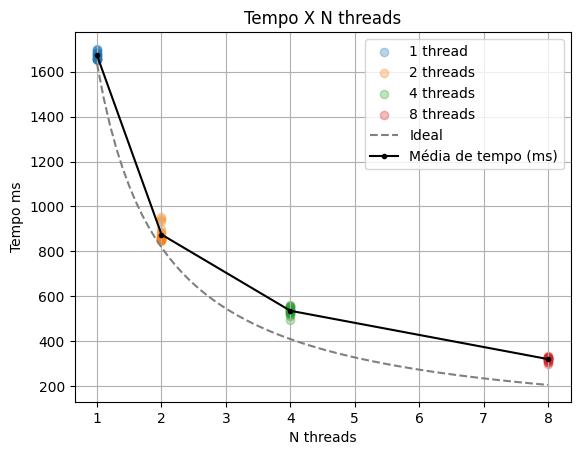

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter([1]*len(res01.tempo), res01.tempo, alpha=0.3, label="1 thread")
plt.scatter([2]*len(res02.tempo), res02.tempo, alpha=0.3, label="2 threads")
plt.scatter([4]*len(res04.tempo), res04.tempo, alpha=0.3, label="4 threads")
plt.scatter([8]*len(res08.tempo), res08.tempo, alpha=0.3, label="8 threads")
plt.plot(np.arange(1, 8.1, 0.1), [t_serial/x for x in np.arange(1, 8.1, 0.1)], "--", color="grey", label = "Ideal")
plt.plot(df_resumo["N threads"], df_resumo["Méd tempo (ms)"], color="black", label="Média de tempo (ms)", marker=".")
plt.grid(True)
plt.xlabel("N threads")
plt.ylabel("Tempo ms")
plt.title("Tempo X N threads")
plt.legend()
plt.show()

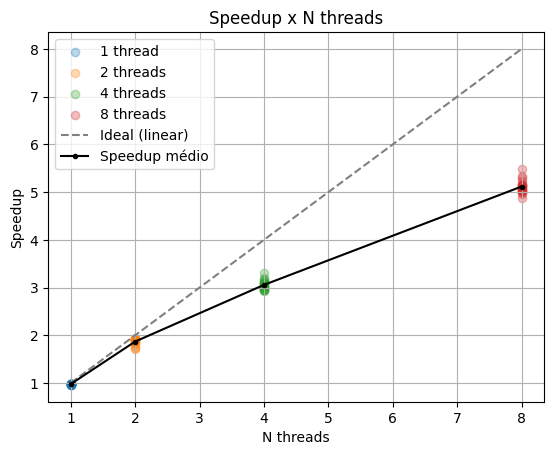

In [4]:
plt.scatter([1]*len(res01.tempo), t_serial/res01.tempo, alpha=0.3, label="1 thread")
plt.scatter([2]*len(res02.tempo), t_serial/res02.tempo, alpha=0.3, label="2 threads")
plt.scatter([4]*len(res04.tempo), t_serial/res04.tempo, alpha=0.3, label="4 threads")
plt.scatter([8]*len(res08.tempo), t_serial/res08.tempo, alpha=0.3, label="8 threads")
plt.plot([1,8], [1,8], "--", color="gray", label="Ideal (linear)")
plt.plot(df_resumo["N threads"], df_resumo["Speedup méd"], color="black", label="Speedup médio", marker=".")
plt.grid(True)
plt.xlabel("N threads")
plt.ylabel("Speedup")
plt.title("Speedup x N threads")
plt.legend()
plt.show()

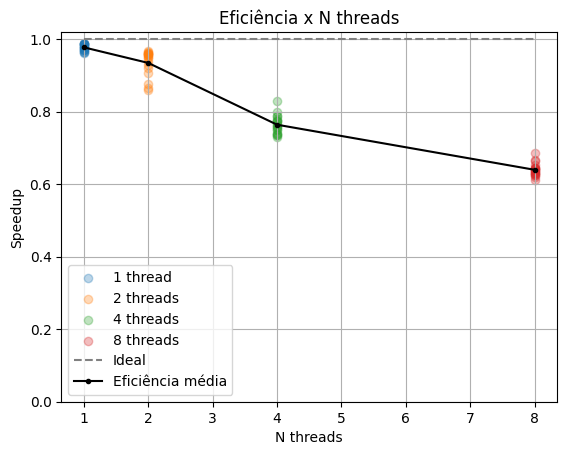

In [5]:
plt.scatter([1]*len(res01.tempo), t_serial/res01.tempo/1, alpha=0.3, label="1 thread")
plt.scatter([2]*len(res02.tempo), t_serial/res02.tempo/2, alpha=0.3, label="2 threads")
plt.scatter([4]*len(res04.tempo), t_serial/res04.tempo/4, alpha=0.3, label="4 threads")
plt.scatter([8]*len(res08.tempo), t_serial/res08.tempo/8, alpha=0.3, label="8 threads")
plt.plot([1,8], [1,1], "--", color="gray", label="Ideal")
plt.plot(df_resumo["N threads"], df_resumo["Eficiência"], color="black", label="Eficiência média", marker=".")
plt.grid(True)
plt.xlabel("N threads")
plt.ylabel("Speedup")
plt.ylim(bottom=0)
plt.title("Eficiência x N threads")
plt.legend()
plt.show()